### Strategy 4: Avellaneda–Stoikov Reservation Price Execution Timing

This strategy adapts the Avellaneda–Stoikov optimal market-making framework to a constrained execution setting where exactly **one share per minute per stock** must be traded. Instead of using the model to quote both bid and ask prices simultaneously, we use its **reservation price** as a timing signal to decide when within each minute to execute a trade.

In the original Avellaneda–Stoikov model, the reservation price adjusts dynamically based on inventory risk. A trader holding large inventory becomes more willing to sell aggressively, while a trader with negative inventory becomes more willing to buy. In this project, inventory is reinterpreted as the **remaining number of shares to execute**, which is equivalent to the **remaining number of minutes in the trading horizon**.

At each time step, the reservation price is computed as $r(s,q,t) = s - q \gamma \sigma^2 (T - t)$

where:

* $s$ is the current midprice,
* $q$ is the remaining shares to execute,
* $\gamma$ is a risk-aversion parameter,
* $\sigma^2$ is short-term price variance,
* (T - t) is the remaining fraction of the execution horizon.

For a **buy strategy**, execution occurs when the best ask price becomes lower than or equal to the reservation price. Otherwise, the algorithm waits within the minute to seek a better opportunity. For a **sell strategy**, execution occurs when the best bid price exceeds the reservation price. If no execution signal appears before the end of the minute, the algorithm submits an aggressive order to guarantee completion of the required trade.

Compared with TWAP, which executes mechanically at the beginning of each minute, this approach dynamically adjusts execution timing based on volatility, remaining execution pressure, and time remaining in the horizon. The goal is to reduce execution cost for buy programs and improve execution price for sell programs while still satisfying the one-trade-per-minute constraint.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
data_path = Path("../Project_Train_Datasets")
amzn = pd.read_csv(data_path / "AMZN_5levels_train.csv")
goog = pd.read_csv(data_path / "GOOG_5levels_train.csv")
intc = pd.read_csv(data_path / "INTC_5levels_train.csv")
msft = pd.read_csv(data_path / "MSFT_5levels_train.csv")

In [3]:
amzn.columns

Index(['Time', 'BidPrice_5', 'BidPrice_4', 'BidPrice_3', 'BidPrice_2',
       'BidPrice_1', 'BidSize_5', 'BidSize_4', 'BidSize_3', 'BidSize_2',
       'BidSize_1', 'AskPrice_1', 'AskPrice_2', 'AskPrice_3', 'AskPrice_4',
       'AskPrice_5', 'AskSize_1', 'AskSize_2', 'AskSize_3', 'AskSize_4',
       'AskSize_5', 'OrderID', 'Size', 'Price', 'Direction_1=Buy_-1=Sell',
       'NewLimitOrder_1=Yes_0=No', 'PartialCancel_1=Yes_0=No',
       'FullDelete_1=Yes_0=No', 'VisibleExecution_1=Yes_0=No',
       'HiddenExecution_1=Yes_0=No', 'TradingHalt_1=Yes_0=No', 'Spread',
       'MidPrice'],
      dtype='object')

In [4]:
amzn['Time'].describe()

count           175338
unique           98797
top       12:43:48.066
freq                33
Name: Time, dtype: object

In [5]:
# Convert 'Time' column to datetime format
# Compute Log return on midprice
def preprocess_lob(df):
    df = df.copy()
    
    # convert time string to datetime
    df["ts"] = pd.to_datetime(df["Time"], format="%H:%M:%S.%f")
    
    # minute bucket for the “1 share per minute” requirement
    df["minute"] = df["ts"].dt.floor("min")
    
    # row index within each minute
    df["row_in_minute"] = df.groupby("minute").cumcount()
    
    # basic log return on midprice for volatility estimate
    df["log_mid"] = np.log(df["MidPrice"])
    df["log_ret"] = df["log_mid"].diff()
    
    return df

amzn = preprocess_lob(amzn)
goog = preprocess_lob(goog)
intc = preprocess_lob(intc)
msft = preprocess_lob(msft)

In [6]:
amzn[["ts", "minute", "BidPrice_1", "AskPrice_1", "MidPrice", "Spread"]].head()

,ts,minute,BidPrice_1,AskPrice_1,MidPrice,Spread
0,1900-01-01 09:30:00.017,1900-01-01 09:30:00,223.18,223.95,223.565,0.77
1,1900-01-01 09:30:00.189,1900-01-01 09:30:00,223.81,223.95,223.880,0.14
2,1900-01-01 09:30:00.189,1900-01-01 09:30:00,223.81,223.95,223.880,0.14
3,1900-01-01 09:30:00.189,1900-01-01 09:30:00,223.81,223.95,223.880,0.14
4,1900-01-01 09:30:00.189,1900-01-01 09:30:00,223.81,223.95,223.880,0.14


In [7]:
# Add remaining inventory and time to the end of the minute
def add_remaining_inventory(df):
    df = df.copy()
    unique_minutes = np.sort(df["minute"].unique())
    total_minutes = len(unique_minutes)
    
    minute_to_q = {
        minute: total_minutes - i
        for i, minute in enumerate(unique_minutes)
    }
    
    df["q_remaining"] = df["minute"].map(minute_to_q)
    df["T_remaining"] = df["q_remaining"] / total_minutes
    
    return df

amzn = add_remaining_inventory(amzn)
goog = add_remaining_inventory(goog)
intc = add_remaining_inventory(intc)
msft = add_remaining_inventory(msft)

In [8]:
amzn[["ts", "minute", "q_remaining", "T_remaining"]].head(10)

,ts,minute,q_remaining,T_remaining
0,1900-01-01 09:30:00.017,1900-01-01 09:30:00,270,1.0
1,1900-01-01 09:30:00.189,1900-01-01 09:30:00,270,1.0
2,1900-01-01 09:30:00.189,1900-01-01 09:30:00,270,1.0
3,1900-01-01 09:30:00.189,1900-01-01 09:30:00,270,1.0
4,1900-01-01 09:30:00.189,1900-01-01 09:30:00,270,1.0
5,1900-01-01 09:30:00.189,1900-01-01 09:30:00,270,1.0
6,1900-01-01 09:30:00.189,1900-01-01 09:30:00,270,1.0
7,1900-01-01 09:30:00.189,1900-01-01 09:30:00,270,1.0
8,1900-01-01 09:30:00.189,1900-01-01 09:30:00,270,1.0
9,1900-01-01 09:30:00.189,1900-01-01 09:30:00,270,1.0


In [9]:
# Estimate volatility using log return
def add_sigma2(df, window=50):
    df = df.copy()
    df["sigma2"] = df["log_ret"].rolling(window).var()
    # fill in NaN with overall variance
    df["sigma2"] = df["sigma2"].fillna(df["log_ret"].var())
    return df

amzn = add_sigma2(amzn)
goog = add_sigma2(goog)
intc = add_sigma2(intc)
msft = add_sigma2(msft)

In [10]:
# Compute reservation price based on Stoikov's formula
def add_reservation_price(df, gamma=0.1, side="buy"):
    df = df.copy()
    
    # In Stoikov's model, the price is compted as less the inventory penalty for bid, and plus the inventory penalty for ask
    if side == "buy":
        df["reservation_price"] = (
            df["MidPrice"]
            - df["q_remaining"] * gamma * df["sigma2"] * df["T_remaining"]
        )
    elif side == "sell":
        df["reservation_price"] = (
            df["MidPrice"]
            + df["q_remaining"] * gamma * df["sigma2"] * df["T_remaining"]
        )
    else:
        raise ValueError("side must be 'buy' or 'sell'")
    
    return df

gamma = 0.1
amzn_buy = add_reservation_price(amzn, gamma=gamma, side="buy")
amzn_sell = add_reservation_price(amzn, gamma=gamma, side="sell")
goog_sell = add_reservation_price(goog, gamma=gamma, side="sell")
goog_buy = add_reservation_price(goog, gamma=gamma, side="buy")
intc_sell = add_reservation_price(intc, gamma=gamma, side="sell")
intc_buy = add_reservation_price(intc, gamma=gamma, side="buy")
msft_sell = add_reservation_price(msft, gamma=gamma, side="sell")
msft_buy = add_reservation_price(msft, gamma=gamma, side="buy")

In [11]:
# Execution logic
def run_stoikov_execution(df, side="buy", gamma=0.1, fallback_last_row=True):
    df = df.copy()
    df = add_reservation_price(df, gamma=gamma, side=side)
    
    executions = []
    
    for minute, g in df.groupby("minute", sort=True):
        g = g.sort_values("ts").reset_index(drop=True)
        executed = False
        
        for _, row in g.iterrows():
            if side == "buy":
                if row["AskPrice_1"] <= row["reservation_price"]:
                    executions.append({
                        "minute": minute,
                        "exec_time": row["ts"],
                        "side": side,
                        "exec_price": row["AskPrice_1"],
                        "midprice": row["MidPrice"],
                        "reservation_price": row["reservation_price"],
                        "q_remaining": row["q_remaining"],
                        "reason": "trigger"
                    })
                    executed = True
                    break
                    
            elif side == "sell":
                if row["BidPrice_1"] >= row["reservation_price"]:
                    executions.append({
                        "minute": minute,
                        "exec_time": row["ts"],
                        "side": side,
                        "exec_price": row["BidPrice_1"],
                        "midprice": row["MidPrice"],
                        "reservation_price": row["reservation_price"],
                        "q_remaining": row["q_remaining"],
                        "reason": "trigger"
                    })
                    executed = True
                    break
        
        if not executed:
            row = g.iloc[-1] if fallback_last_row else g.iloc[0]
            executions.append({
                "minute": minute,
                "exec_time": row["ts"],
                "side": side,
                "exec_price": row["AskPrice_1"] if side == "buy" else row["BidPrice_1"],
                "midprice": row["MidPrice"],
                "reservation_price": row["reservation_price"],
                "q_remaining": row["q_remaining"],
                "reason": "forced_end_of_minute"
            })
    
    return pd.DataFrame(executions)

In [12]:
amzn_buy_exec = run_stoikov_execution(amzn, side="buy", gamma=0.1)
amzn_sell_exec = run_stoikov_execution(amzn, side="sell", gamma=0.1)
goog_buy_exec = run_stoikov_execution(goog, side="buy", gamma=0.1)
goog_sell_exec = run_stoikov_execution(goog, side="sell", gamma=0.1)
intc_buy_exec = run_stoikov_execution(intc, side="buy", gamma=0.1)
intc_sell_exec = run_stoikov_execution(intc, side="sell", gamma=0.1)
msft_buy_exec = run_stoikov_execution(msft, side="buy", gamma=0.1)
msft_sell_exec = run_stoikov_execution(msft, side="sell", gamma=0.1)

In [13]:
# Baseline Strategy: TWAP execution
def run_twap_execution(df, side="buy"):
    executions = []

    for minute, g in df.groupby("minute", sort=True):
        g = g.sort_values("ts")

        first_row = g.iloc[0]

        if side == "buy":
            exec_price = first_row["AskPrice_1"]
        else:
            exec_price = first_row["BidPrice_1"]

        executions.append({
            "minute": minute,
            "exec_time": first_row["ts"],
            "side": side,
            "exec_price": exec_price
        })

    return pd.DataFrame(executions)

In [14]:
# score function:
# - for buy: lower execution price is better
# - for sell: higher execution price is better
def compute_improvement(stoikov_exec, twap_exec, side):
    stoikov_avg = stoikov_exec["exec_price"].mean()
    twap_avg = twap_exec["exec_price"].mean()

    if side == "buy":
        improvement = twap_avg - stoikov_avg
    elif side == "sell":
        improvement = stoikov_avg - twap_avg
    else:
        raise ValueError("side must be 'buy' or 'sell'")

    return improvement, stoikov_avg, twap_avg

In [15]:
# Backtest results comparison
# Diagnostics: how often do we actually trigger instead of forcing at minute end?
def summarize_execution(exec_df, stock, side):
    return {
        "Stock": stock,
        "Side": side,
        "Trades": len(exec_df),
        "Trigger Rate": (exec_df["reason"] == "trigger").mean(),
        "Forced Rate": (exec_df["reason"] == "forced_end_of_minute").mean(),
        "Avg Exec Price": exec_df["exec_price"].mean()
    }

In [16]:
def grid_search_gamma(df, side, gamma_grid):
    twap_exec = run_twap_execution(df, side=side)
    results = []

    for gamma in gamma_grid:
        stoikov_exec = run_stoikov_execution(df, side=side, gamma=gamma)
        improvement, stoikov_avg, twap_avg = compute_improvement(
            stoikov_exec, twap_exec, side
        )

        results.append({
            "side": side,
            "gamma": gamma,
            "stoikov_avg": stoikov_avg,
            "twap_avg": twap_avg,
            "improvement": improvement,
            "trigger_rate": (stoikov_exec["reason"] == "trigger").mean(),
            "forced_rate": (stoikov_exec["reason"] == "forced_end_of_minute").mean()
        })

    results = pd.DataFrame(results).sort_values("improvement", ascending=False).reset_index(drop=True)
    return results

In [17]:
gamma_grid = np.geomspace(1e-4, 1e6, 25)

amzn_buy_search  = grid_search_gamma(amzn, side="buy", gamma_grid=gamma_grid)
amzn_sell_search = grid_search_gamma(amzn, side="sell", gamma_grid=gamma_grid)

goog_buy_search  = grid_search_gamma(goog, side="buy", gamma_grid=gamma_grid)
goog_sell_search = grid_search_gamma(goog, side="sell", gamma_grid=gamma_grid)

intc_buy_search  = grid_search_gamma(intc, side="buy", gamma_grid=gamma_grid)
intc_sell_search = grid_search_gamma(intc, side="sell", gamma_grid=gamma_grid)

msft_buy_search  = grid_search_gamma(msft, side="buy", gamma_grid=gamma_grid)
msft_sell_search = grid_search_gamma(msft, side="sell", gamma_grid=gamma_grid)

In [21]:
# Pick best gamma separately for each stock and side
best_gammas = {
    "AMZN": {
        "buy":  amzn_buy_search.iloc[0]["gamma"],
        "sell": amzn_sell_search.iloc[0]["gamma"]
    },
    "GOOG": {
        "buy":  goog_buy_search.iloc[0]["gamma"],
        "sell": goog_sell_search.iloc[0]["gamma"]
    },
    "INTC": {
        "buy":  intc_buy_search.iloc[0]["gamma"],
        "sell": intc_sell_search.iloc[0]["gamma"]
    },
    "MSFT": {
        "buy":  msft_buy_search.iloc[0]["gamma"],
        "sell": msft_sell_search.iloc[0]["gamma"]
    }
}

# Backtest results comparison
def compare_execution_prices(stock_name,
                             stoikov_buy, twap_buy,
                             stoikov_sell, twap_sell):

    buy_stoikov = stoikov_buy["exec_price"].mean()
    buy_twap = twap_buy["exec_price"].mean()

    sell_stoikov = stoikov_sell["exec_price"].mean()
    sell_twap = twap_sell["exec_price"].mean()

    return {
        "Stock": stock_name,
        "TWAP Buy": buy_twap,
        "Stoikov Buy": buy_stoikov,
        "Buy Improvement": buy_twap - buy_stoikov,
        "TWAP Sell": sell_twap,
        "Stoikov Sell": sell_stoikov,
        "Sell Improvement": sell_stoikov - sell_twap,
        "Best Buy Gamma": best_gammas[stock_name]["buy"],
        "Best Sell Gamma": best_gammas[stock_name]["sell"],
        "Buy Trigger Rate": (stoikov_buy["reason"] == "trigger").mean(),
        "Sell Trigger Rate": (stoikov_sell["reason"] == "trigger").mean()
    }

amzn_twap_buy = run_twap_execution(amzn, "buy")
amzn_twap_sell = run_twap_execution(amzn, "sell")
goog_twap_buy = run_twap_execution(goog, "buy")
goog_twap_sell = run_twap_execution(goog, "sell")
intc_twap_buy = run_twap_execution(intc, "buy")
intc_twap_sell = run_twap_execution(intc, "sell")
msft_twap_buy = run_twap_execution(msft, "buy")
msft_twap_sell = run_twap_execution(msft, "sell")

comparison_table = pd.DataFrame([
    compare_execution_prices(
        "AMZN",
        amzn_buy_exec, amzn_twap_buy,
        amzn_sell_exec, amzn_twap_sell
    ),
    compare_execution_prices(
        "GOOG",
        goog_buy_exec, goog_twap_buy,
        goog_sell_exec, goog_twap_sell
    ),
    compare_execution_prices(
        "INTC",
        intc_buy_exec, intc_twap_buy,
        intc_sell_exec, intc_twap_sell
    ),
    compare_execution_prices(
        "MSFT",
        msft_buy_exec, msft_twap_buy,
        msft_sell_exec, msft_twap_sell
    )
])

comparison_table

,Stock,TWAP Buy,Stoikov Buy,Buy Improvement,TWAP Sell,Stoikov Sell,Sell Improvement,Best Buy Gamma,Best Sell Gamma,Buy Trigger Rate,Sell Trigger Rate
0,AMZN,223.519370,223.512444,0.006926,223.380481,223.373704,-0.006778,0.0001,0.0001,0.0,0.0
1,GOOG,572.593259,572.551111,0.042148,572.300222,572.259926,-0.040296,0.0001,0.0001,0.0,0.0
2,INTC,27.160778,27.158185,0.002593,27.150556,27.148000,-0.002556,0.0001,0.0001,0.0,0.0
3,MSFT,30.684556,30.682519,0.002037,30.674370,30.672444,-0.001926,0.0001,0.0001,0.0,0.0


In [24]:
# Diagnostic: inspect how far market prices are from the reservation trigger

def diagnostic_threshold_distance(df, side="buy", gamma=0.1):
    tmp = add_reservation_price(df, gamma=gamma, side=side).copy()

    if side == "buy":
        tmp["trigger_gap"] = tmp["AskPrice_1"] - tmp["reservation_price"]
        # trigger happens when trigger_gap <= 0
    else:
        tmp["trigger_gap"] = tmp["reservation_price"] - tmp["BidPrice_1"]
        # trigger happens when trigger_gap <= 0

    summary = {
        "side": side,
        "gamma": gamma,
        "mean_gap": tmp["trigger_gap"].mean(),
        "median_gap": tmp["trigger_gap"].median(),
        "min_gap": tmp["trigger_gap"].min(),
        "max_gap": tmp["trigger_gap"].max(),
        "pct_triggerable": (tmp["trigger_gap"] <= 0).mean(),
    }
    return tmp, summary

amzn_buy_diag_df, amzn_buy_diag_summary = diagnostic_threshold_distance(amzn, side="buy", gamma=0.0001)
amzn_sell_diag_df, amzn_sell_diag_summary = diagnostic_threshold_distance(amzn, side="sell", gamma=0.0001)

amzn_buy_diag_summary, amzn_sell_diag_summary

({'side': 'buy',
  'gamma': 0.0001,
  'mean_gap': np.float64(0.07070381209122535),
  'median_gap': np.float64(0.07000000000033424),
  'min_gap': np.float64(0.005000000000023874),
  'max_gap': np.float64(0.3850000000375644),
  'pct_triggerable': np.float64(0.0)},
 {'side': 'sell',
  'gamma': 0.0001,
  'mean_gap': np.float64(0.07070381209122523),
  'median_gap': np.float64(0.07000000000036266),
  'min_gap': np.float64(0.005000000000023874),
  'max_gap': np.float64(0.3850000000375644),
  'pct_triggerable': np.float64(0.0)})

In [22]:
# Final comparison table
backtest_table = comparison_table.copy()

avg_row = pd.DataFrame([{
    "Stock": "Overall Avg",
    "TWAP Buy": backtest_table["TWAP Buy"].mean(),
    "Stoikov Buy": backtest_table["Stoikov Buy"].mean(),
    "Buy Improvement": backtest_table["Buy Improvement"].mean(),
    "TWAP Sell": backtest_table["TWAP Sell"].mean(),
    "Stoikov Sell": backtest_table["Stoikov Sell"].mean(),
    "Sell Improvement": backtest_table["Sell Improvement"].mean(),
    "Best Buy Gamma": backtest_table["Best Buy Gamma"].mean(),
    "Best Sell Gamma": backtest_table["Best Sell Gamma"].mean(),
    "Buy Trigger Rate": backtest_table["Buy Trigger Rate"].mean(),
    "Sell Trigger Rate": backtest_table["Sell Trigger Rate"].mean(),
}]).round(6)

backtest_table = pd.concat([backtest_table.round(6), avg_row], ignore_index=True)
backtest_table.to_csv("Strategy_4_Backtest_Results.csv", index=False)
backtest_table

,Stock,TWAP Buy,Stoikov Buy,Buy Improvement,TWAP Sell,Stoikov Sell,Sell Improvement,Best Buy Gamma,Best Sell Gamma,Buy Trigger Rate,Sell Trigger Rate
0,AMZN,223.519370,223.512444,0.006926,223.380481,223.373704,-0.006778,0.0001,0.0001,0.0,0.0
1,GOOG,572.593259,572.551111,0.042148,572.300222,572.259926,-0.040296,0.0001,0.0001,0.0,0.0
2,INTC,27.160778,27.158185,0.002593,27.150556,27.148000,-0.002556,0.0001,0.0001,0.0,0.0
3,MSFT,30.684556,30.682519,0.002037,30.674370,30.672444,-0.001926,0.0001,0.0001,0.0,0.0
4,Overall Avg,213.489491,213.476065,0.013426,213.376407,213.363519,-0.012889,0.0001,0.0001,0.0,0.0


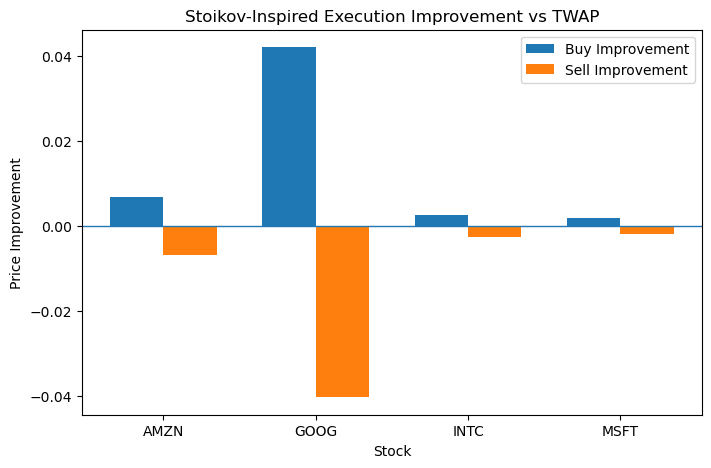

In [23]:
plot_df = comparison_table.copy()

x = np.arange(len(plot_df["Stock"]))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, plot_df["Buy Improvement"], width, label="Buy Improvement")
plt.bar(x + width/2, plot_df["Sell Improvement"], width, label="Sell Improvement")

plt.axhline(0, linewidth=1)
plt.xticks(x, plot_df["Stock"])
plt.title("Stoikov-Inspired Execution Improvement vs TWAP")
plt.ylabel("Price Improvement")
plt.xlabel("Stock")
plt.legend()
plt.show()